In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = np.load("../../GridRaster/part_ours_training/saved_features/item_11.npz", allow_pickle=True)

query_dict = data['query_dict']
support_dict = data['support_dict']
query_full_superpixels = data['query_full_superpixels']
support_part_superpixels = data['support_part_superpixels']
gt_query_part_superpixels = data['gt_query_part_superpixels']
cos_mat_dist = data['cos_mat_dist']

print(query_dict.shape, support_dict.shape, query_full_superpixels.shape, support_part_superpixels.shape, gt_query_part_superpixels.shape, cos_mat_dist.shape)

() () (44,) (7,) (8,) (44, 7)


In [3]:
len(query_full_superpixels), query_full_superpixels, len(support_part_superpixels), support_part_superpixels

(44,
 array([195, 220, 222, 223, 249, 250, 251, 277, 278, 279, 306, 307, 332,
        333, 334, 335, 361, 362, 363, 389, 390, 391, 417, 418, 419, 445,
        446, 447, 473, 474, 475, 501, 502, 503, 528, 529, 530, 531, 556,
        557, 558, 559, 584, 585], dtype=int32),
 7,
 array([309, 336, 337, 338, 365, 366, 393], dtype=int32))

In [4]:
query_dict.item().keys(), support_dict.item().keys()

(dict_keys(['original_image', 'superpixel_overlayed', 'superpixel_labels', 'superpixel_features']),
 dict_keys(['original_image', 'superpixel_overlayed', 'superpixel_labels', 'superpixel_features']))

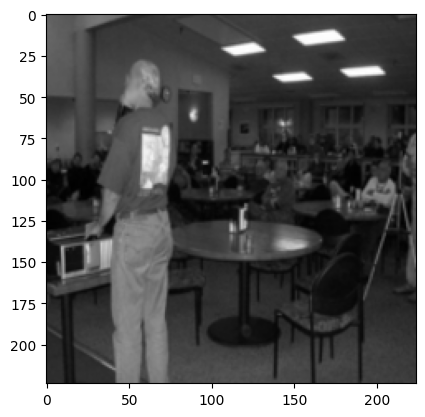

In [5]:
plt.imshow(query_dict.item()['original_image'])

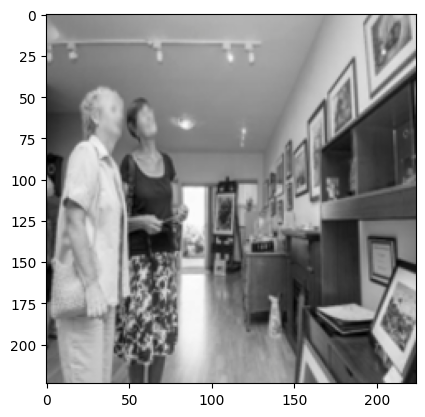

In [6]:
plt.imshow(support_dict.item()['original_image'])

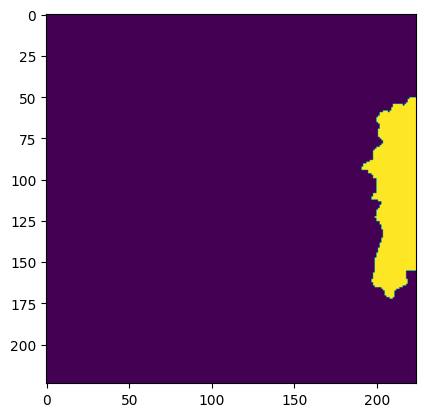

In [7]:
query_full_mask = np.isin(query_dict.item()['superpixel_labels'], query_full_superpixels)
plt.imshow(query_full_mask)

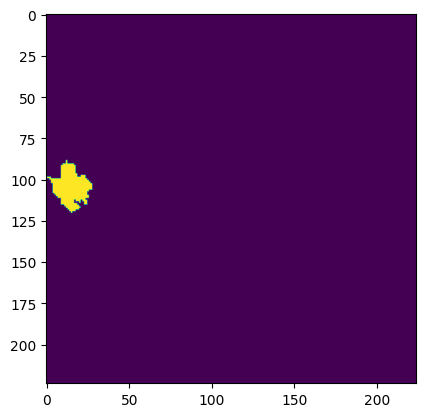

In [8]:
# support_part
part_mask = np.isin(support_dict.item()['superpixel_labels'], support_part_superpixels)
plt.imshow(part_mask) # this is not correct as part here belongs to support but we are printing on query

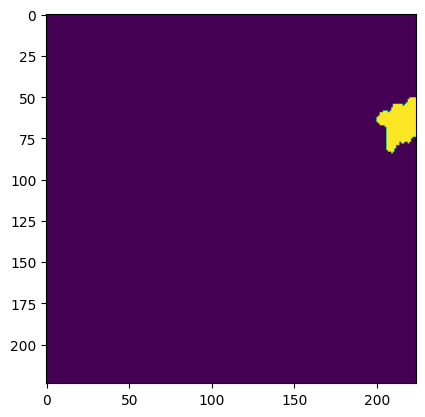

In [9]:
#GT
gt_query_part_mask = np.isin(query_dict.item()['superpixel_labels'], gt_query_part_superpixels)
plt.imshow(gt_query_part_mask)

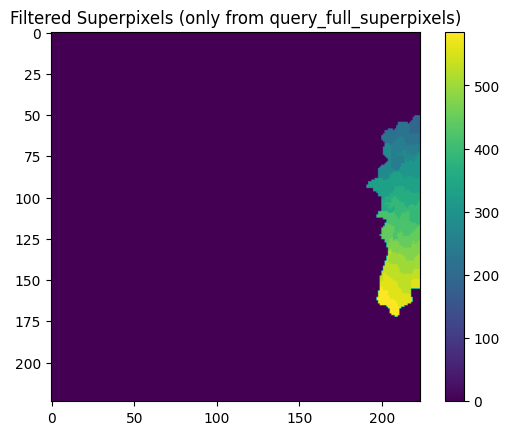

In [5]:
# Create a mask of where superpixel labels are in query_full_superpixels
mask = np.isin(query_dict.item()['superpixel_labels'], query_full_superpixels)

# Optional: Create a masked version of superpixel_labels
# can either keep original label values or set others to 0
filtered_superpixels = np.where(mask, query_dict.item()['superpixel_labels'], 0)


# Show the filtered superpixels
plt.imshow(filtered_superpixels)
plt.title("Filtered Superpixels (only from query_full_superpixels)")
plt.colorbar()
plt.show()

### Simple Implementation (Less Complex model)

In [17]:
img = query_dict.item()['original_image']
#segments = query_dict.item()['superpixel_labels']
segments = filtered_superpixels

In [18]:
import torch
import torch.nn as nn
from torch_geometric.nn import dense_mincut_pool

class MinCutOnlyModel(nn.Module):
    def __init__(self, in_channels, n_clusters):
        super().__init__()
        self.assignment = nn.Linear(in_channels, n_clusters)

    def forward(self, x, adj):
        s = self.assignment(x)  # assignment matrix [num_nodes, n_clusters]
        x_pool, adj_pool, mc_loss, o_loss = dense_mincut_pool(x, adj, s)
        return x_pool, s, mc_loss + o_loss


In [30]:
A = cos_mat_dist @ cos_mat_dist.T
#print(A.shape, type(A), img.shape, type(img))
#y = real_sups_seg # in pytorch y is not required
X = query_dict.item()['superpixel_features'][query_full_superpixels]

In [20]:
A.shape, X.shape

((44, 44), (44, 1024))

In [21]:
ITER = 40000

In [31]:
X_tensor = torch.tensor(X, dtype=torch.float32)
#A_tensor = torch.tensor(A.todense(), dtype=torch.float32)
A_tensor = torch.tensor(A, dtype=torch.float32)

model = MinCutOnlyModel(in_channels=X.shape[1], n_clusters=2)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(ITER):
    model.train()
    optimizer.zero_grad()
    x_pool, assignments, loss = model(X_tensor, A_tensor)
    loss.backward()
    optimizer.step()

# model.train()
# optimizer.zero_grad()
# x_pool, assignments, loss = model(X_tensor, A_tensor)
# loss.backward()
# optimizer.step()


In [32]:
assignments.shape

torch.Size([44, 2])

In [33]:
c = torch.argmax(assignments, dim=1).cpu().numpy()

In [34]:
c

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0])

In [35]:
labels = np.full_like(segments, fill_value=-1)
sp_to_label = dict(zip(query_full_superpixels, c))
for sp_id, label in sp_to_label.items():
    labels[segments == sp_id] = label
labels[labels == -1] = 0  # background

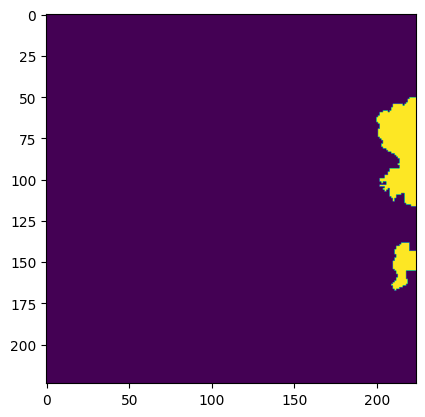

In [36]:
plt.imshow(labels)

In [37]:
X.shape, A.shape, img.shape, segments.shape

((44, 1024), (44, 44), (224, 224, 3), (224, 224))

In [38]:
del A, X

In [39]:
del img, segments

### Using inbuilt feature and affinity creation

In [6]:
img = query_dict.item()['original_image']
#segments = gt_output.item()['superpixel_labels']
segments = filtered_superpixels

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import from_scipy_sparse_matrix, to_dense_adj
from torch_geometric.data import Data
from skimage import segmentation, color
from skimage import graph
from skimage.io import imread
from torch_geometric.nn.dense import dense_mincut_pool
from tqdm import tqdm

# --- CONFIG ---
#OVER_SEG = "felzen"
PLOTS_ON = True
ITER = 4000
NUM_CLUSTERS = 2

# --- BUILD RAG ---
g = graph.rag_mean_color(img, segments, mode='similarity')
A = nx.to_scipy_sparse_array(g, dtype=np.float32)
edge_index, edge_weight = from_scipy_sparse_matrix(A)
    
node_ids = list(g.nodes())
id_map = {old_id: new_id for new_id, old_id in enumerate(node_ids)}
# --- FEATURES ---
X_m = np.empty((A.shape[0], 3))
X_t = np.empty((A.shape[0], 3))
for n, d in g.nodes(data=True):
    new_id = id_map[n]
    X_m[new_id] = d['mean color']
    X_t[new_id] = d['total color']

X_m = (X_m / np.max(X_m)).astype(np.float32)
X_t = (X_t / np.max(X_t)).astype(np.float32)
X = torch.tensor(np.concatenate((X_m, X_t), axis=-1), dtype=torch.float32)

# --- DUMMY BATCH ---
batch = torch.zeros(X.size(0), dtype=torch.long)  # Single graph

# --- CREATE GRAPH DATA ---
data = Data(x=X, edge_index=edge_index, edge_attr=edge_weight, batch=batch)

# --- MINCUT POOL MODULE USING DENSE API ---
class DenseMinCutNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_clusters, num_nodes):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin_assign = nn.Linear(hidden_channels, out_clusters)
        self.num_nodes = num_nodes

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.lin1(x))  # [N, hidden_channels]
        adj = to_dense_adj(edge_index, batch=batch, edge_attr=edge_weight, max_num_nodes=self.num_nodes)
        x = x.view(-1, self.num_nodes, x.size(-1))  # [1, num_nodes, hidden_channels]
        s = F.softmax(self.lin_assign(x), dim=-1)  # [1, num_nodes, out_clusters]
        x_pool, adj_pool, mc_loss, o_loss = dense_mincut_pool(x, adj, s)
        return x_pool, s, mc_loss + o_loss

# --- TRAINING ---
model = DenseMinCutNet(
    in_channels=X.size(1),
    hidden_channels=16,
    out_clusters=NUM_CLUSTERS,
    num_nodes=X.size(0)
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
losses = []

model.train()
for epoch in tqdm(range(ITER)):
    optimizer.zero_grad()
    x_pool, s, loss = model(data.x, data.edge_index, data.edge_attr, data.batch)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

100%|██████████| 4000/4000 [00:04<00:00, 920.00it/s]


In [8]:
c_prime = s.squeeze(0).argmax(dim=-1)

In [9]:
c_prime.shape, query_full_superpixels.shape

(torch.Size([45]), (44,))

In [10]:
labels = np.full_like(segments, fill_value=-1)
sp_to_label = dict(zip(query_full_superpixels, c_prime))
for sp_id, label in sp_to_label.items():
    labels[segments == sp_id] = label
labels[labels == -1] = 0  # background

In [11]:
query_full_superpixels, len(query_full_superpixels)

(array([195, 220, 222, 223, 249, 250, 251, 277, 278, 279, 306, 307, 332,
        333, 334, 335, 361, 362, 363, 389, 390, 391, 417, 418, 419, 445,
        446, 447, 473, 474, 475, 501, 502, 503, 528, 529, 530, 531, 556,
        557, 558, 559, 584, 585], dtype=int32),
 44)

In [12]:
c_prime, len(c_prime)

(tensor([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
         1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]),
 45)

In [13]:
sp_to_label, len(sp_to_label)

({195: tensor(1),
  220: tensor(0),
  222: tensor(0),
  223: tensor(0),
  249: tensor(0),
  250: tensor(0),
  251: tensor(1),
  277: tensor(0),
  278: tensor(0),
  279: tensor(0),
  306: tensor(1),
  307: tensor(0),
  332: tensor(0),
  333: tensor(0),
  334: tensor(1),
  335: tensor(0),
  361: tensor(1),
  362: tensor(0),
  363: tensor(0),
  389: tensor(1),
  390: tensor(1),
  391: tensor(1),
  417: tensor(0),
  418: tensor(1),
  419: tensor(1),
  445: tensor(0),
  446: tensor(0),
  447: tensor(1),
  473: tensor(0),
  474: tensor(0),
  475: tensor(1),
  501: tensor(0),
  502: tensor(1),
  503: tensor(0),
  528: tensor(1),
  529: tensor(0),
  530: tensor(0),
  531: tensor(1),
  556: tensor(0),
  557: tensor(0),
  558: tensor(1),
  559: tensor(0),
  584: tensor(0),
  585: tensor(0)},
 44)

In [14]:
model.eval()
with torch.no_grad():
    _, s, _ = model(data.x, data.edge_index, data.edge_attr, data.batch)
    c = s.squeeze(0).argmax(dim=-1)  # Shape: [num_nodes]

    # Remap segment labels from original superpixel IDs to 0..N-1
    segments_remapped = np.full_like(segments, fill_value=-1)
    for orig_id, new_id in id_map.items():
        segments_remapped[segments == orig_id] = new_id

    # Now safely index using remapped segments
    labels = np.full_like(segments_remapped, fill_value=-1)
    valid = segments_remapped != -1
    labels[valid] = c[segments_remapped[valid]].cpu().numpy()

In [15]:
c.shape

torch.Size([45])

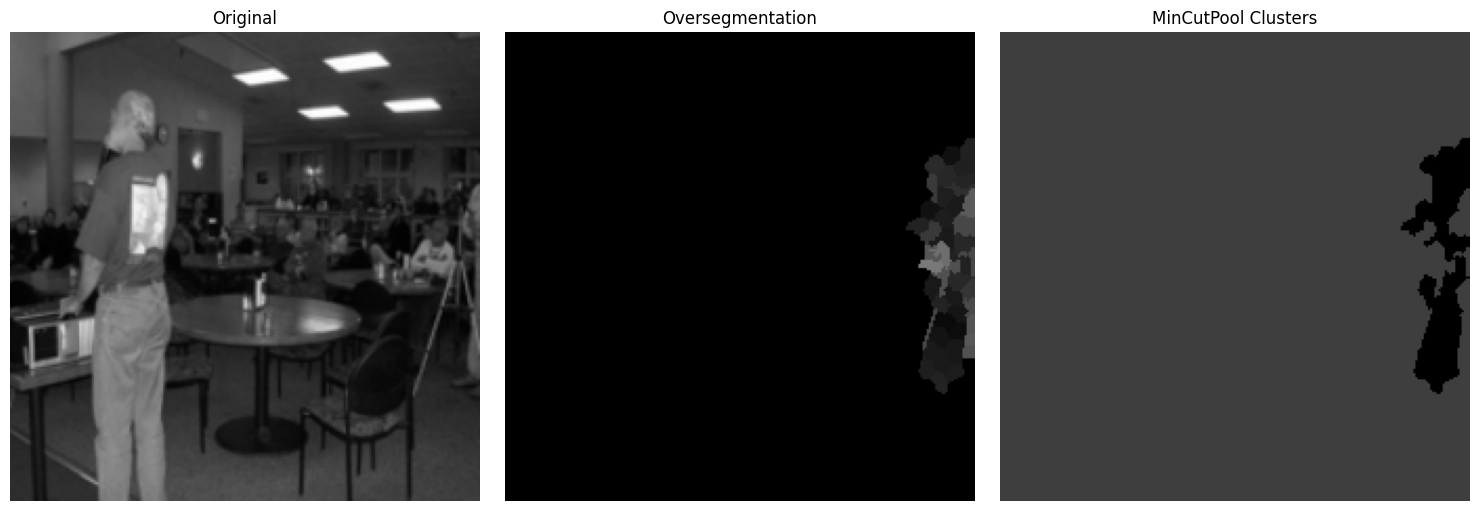

In [16]:
# --- PLOTTING ---
if PLOTS_ON:
    out_seg = color.label2rgb(segments, img, kind='avg')
    out_clust = color.label2rgb(labels, img, kind='avg')
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[1].imshow(out_seg)
    ax[1].set_title("Oversegmentation")
    ax[2].imshow(out_clust)
    ax[2].set_title("MinCutPool Clusters")
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import from_scipy_sparse_matrix, to_dense_adj
from torch_geometric.data import Data
from skimage import segmentation, color, graph
from skimage.io import imread
from tqdm import tqdm
from sklearn.metrics import adjusted_rand_score

# --- CONFIG ---
PLOTS_ON = True
ITER = 4000
NUM_CLUSTERS = 2
beta=0.8

# --- LOAD IMAGE AND GROUND TRUTH PART MASK ---
img = query_dict.item()['original_image']
gt_query_part_seg = np.isin(query_dict.item()['superpixel_labels'], gt_query_part_superpixels)  # assuming GT part mask is grayscale

# --- OVERSEGMENTATION ---
mask = np.isin(query_dict.item()['superpixel_labels'], query_full_superpixels)
segments = np.where(mask, query_dict.item()['superpixel_labels'], 0)

# --- BUILD RAG ---
g = graph.rag_mean_color(img, segments, mode='similarity')
node_ids = list(g.nodes())
id_map = {old_id: new_id for new_id, old_id in enumerate(node_ids)}

# --- FEATURES ---
X_m = np.empty((len(node_ids), 3))
X_t = np.empty((len(node_ids), 3))
for n, d in g.nodes(data=True):
    new_id = id_map[n]
    X_m[new_id] = d['mean color']
    X_t[new_id] = d['total color']

X_m = (X_m / np.max(X_m)).astype(np.float32)
X_t = (X_t / np.max(X_t)).astype(np.float32)
X = torch.tensor(np.concatenate((X_m, X_t), axis=-1), dtype=torch.float32)

# --- BUILD GRAPH ---
A = nx.to_scipy_sparse_array(g, dtype=np.float32)
edge_index, edge_weight = from_scipy_sparse_matrix(A)
batch = torch.zeros(X.size(0), dtype=torch.long)  # Single graph
data = Data(x=X, edge_index=edge_index, edge_attr=edge_weight, batch=batch)

# --- GROUND TRUTH PART LABELS FOR SUPERVISED LOSS ---
superpixel_gt_labels = np.full(len(id_map), -1)  # Initialize
for orig_id, new_id in id_map.items():
    mask = segments == orig_id
    labels_in_part_seg = gt_query_part_seg[mask]
    if len(labels_in_part_seg) == 0:
        continue
    values, counts = np.unique(labels_in_part_seg, return_counts=True)
    superpixel_gt_labels[new_id] = values[np.argmax(counts)]

valid_nodes = superpixel_gt_labels >= 0
supervised_labels = torch.tensor(superpixel_gt_labels[valid_nodes], dtype=torch.long)

# --- MODEL ---
class DenseMinCutNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_clusters, num_nodes):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin_assign = nn.Linear(hidden_channels, out_clusters)
        self.num_nodes = num_nodes

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.lin1(x))  # [N, hidden_channels]
        adj = to_dense_adj(edge_index, batch=batch, edge_attr=edge_weight, max_num_nodes=self.num_nodes)
        x = x.view(-1, self.num_nodes, x.size(-1))  # [1, num_nodes, hidden_channels]
        s = F.softmax(self.lin_assign(x), dim=-1)  # [1, num_nodes, out_clusters]
        from torch_geometric.nn import dense_mincut_pool
        x_pool, adj_pool, mc_loss, o_loss = dense_mincut_pool(x, adj, s)
        return x_pool, s, mc_loss + o_loss

# --- TRAINING ---
model = DenseMinCutNet(X.size(1), 16, NUM_CLUSTERS, X.size(0))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
sup_loss_fn = nn.CrossEntropyLoss()
losses, sup_losses, unsup_losses = [], [], []

model.train()
for epoch in tqdm(range(50000)):
    optimizer.zero_grad()
    x_pool, s, unsup_loss = model(data.x, data.edge_index, data.edge_attr, data.batch)
    logits = s.squeeze(0)  # [num_nodes, NUM_CLUSTERS]
    sup_loss = sup_loss_fn(logits[valid_nodes], supervised_labels)
    total_loss = ((beta * unsup_loss) + ((1-beta) * sup_loss))
    #total_loss = unsup_loss
    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())
    sup_losses.append(sup_loss.item())
    unsup_losses.append(unsup_loss.item())


100%|██████████| 50000/50000 [01:00<00:00, 824.69it/s]


In [23]:
supervised_labels

tensor([0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [24]:
min(sup_losses), np.argmin(sup_losses), sup_losses[14139]

(0.4910394847393036, 13786, 0.49103957414627075)

In [20]:
min(unsup_losses), np.argmin(unsup_losses), unsup_losses[149]

(-0.23585546016693115, 160, -0.2358335256576538)

In [21]:
min(losses), np.argmin(losses), losses[14139]

(-0.08949875086545944, 13498, -0.0894986018538475)

In [22]:
logits.argmax(dim=-1)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [1]:
#logits, logits[valid_nodes]

In [25]:
# --- EVALUATION ---
model.eval()
with torch.no_grad():
    _, s, _ = model(data.x, data.edge_index, data.edge_attr, data.batch)
    pred_labels = s.squeeze(0).argmax(dim=-1)
    segments_remapped = np.full_like(segments, -1)
    for orig_id, new_id in id_map.items():
        segments_remapped[segments == orig_id] = new_id
    labels_img = np.full_like(segments_remapped, -1)
    valid = segments_remapped != -1
    labels_img[valid] = pred_labels[segments_remapped[valid]].cpu().numpy()
    

In [26]:
pred_labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

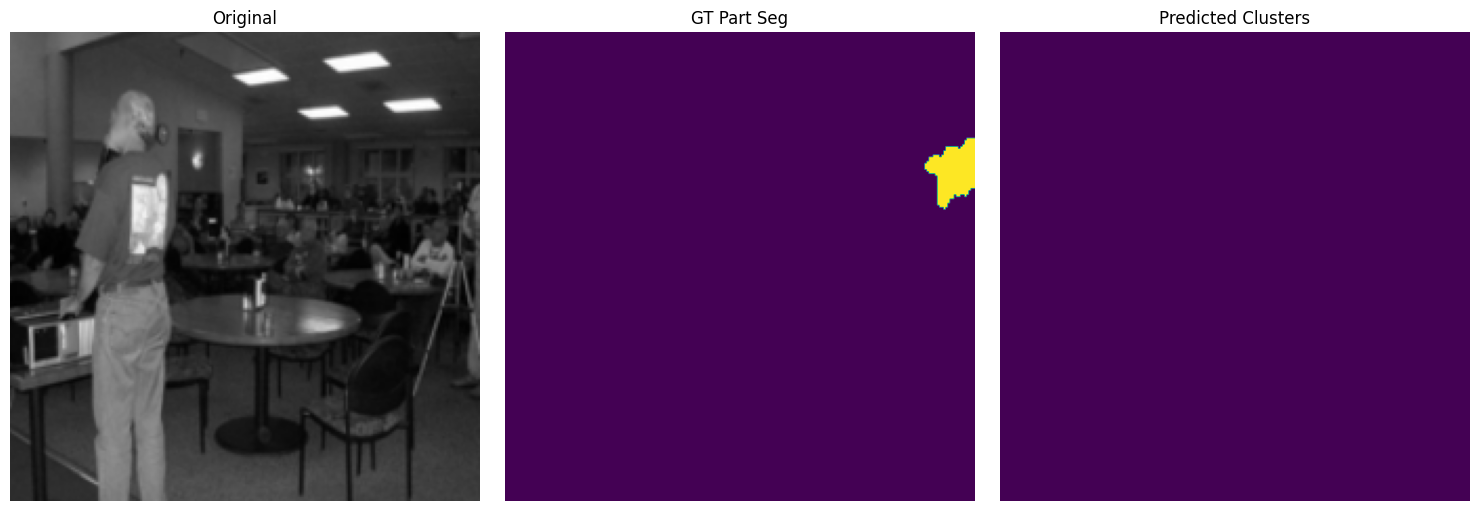

In [27]:
if PLOTS_ON:
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[1].imshow(gt_query_part_seg)
    ax[1].set_title("GT Part Seg") # need to rewrite again
    ax[2].imshow(labels_img)
    ax[2].set_title("Predicted Clusters")
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()

In [28]:
 # Cluster evaluation
y_true = superpixel_gt_labels[valid_nodes]
y_pred = pred_labels[valid_nodes].cpu().numpy()
print("Adjusted Rand Index (ARI):", adjusted_rand_score(y_true, y_pred))

Adjusted Rand Index (ARI): 0.0


In [29]:
y_true

array([0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0])

In [30]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0])

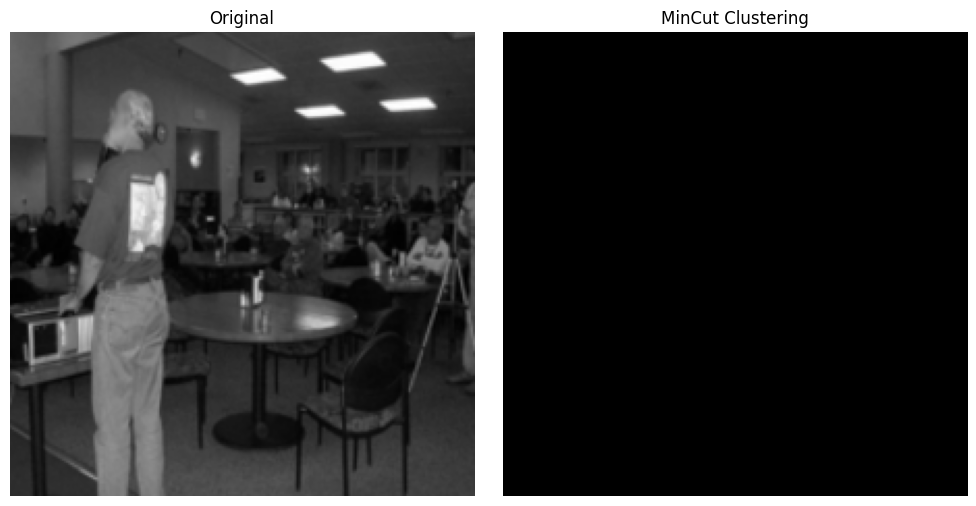

In [31]:
if PLOTS_ON:
    from skimage import color
    out_clust = color.label2rgb(labels_img, img, kind='avg')
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[1].imshow(out_clust)
    ax[1].set_title("MinCut Clustering")
    for a in ax:
        a.axis('off')
    plt.tight_layout()
    plt.show()

In [91]:
del X, A, s, img, segments

### Pytorch implementation on DINO features and Affinity=cos_dist_mat 

In [8]:
import torch
import torch.nn as nn
from torch_geometric.data import Data

#from model import Net
from model import DenseMinCutNet
from torch_geometric.nn.conv.gcn_conv import gcn_norm

In [9]:
# Prepare your input graph
X = torch.tensor(query_dict.item()['superpixel_features'][query_full_superpixels], dtype=torch.float32)
adj = cos_mat_dist @ cos_mat_dist.T
adj = torch.tensor(adj, dtype=torch.float32)

# Superpixel ID remapping
id_map = {orig_id: new_id for new_id, orig_id in enumerate(query_full_superpixels)}

# Convert to sparse format
edge_index = (adj > 0).nonzero(as_tuple=False).t()
edge_weight = adj[edge_index[0], edge_index[1]]

# Ground truth part labels for evaluation
#y = torch.tensor(gt_query_part_superpixels, dtype=torch.long)

# Create PyG Data object
#data = Data(x=X, edge_index=edge_index, edge_weight=edge_weight, y=y)
data = Data(x=X, edge_index=edge_index, edge_weight=edge_weight)

# Normalize edge weights
# from torch_geometric.nn import gcn_norm
data.edge_index, data.edge_weight = gcn_norm(
    data.edge_index, data.edge_weight, data.num_nodes,
    add_self_loops=False, dtype=data.x.dtype
)


In [10]:
data

Data(x=[44, 1024], edge_index=[2, 1936], edge_weight=[1936])

In [11]:
ITER = 50000
NUM_CLUSTERS = 2

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, 
                 mp_units,
                 mp_act,
                 in_channels, 
                 n_clusters, 
                 mlp_units=[],
                 mlp_act="Identity"):
        super().__init__()
        
        mp_act = getattr(torch.nn, mp_act)(inplace=True)
        mlp_act = getattr(torch.nn, mlp_act)(inplace=True)
        
        # Message passing layers
        mp = [
            (GraphConv(in_channels, mp_units[0]), 'x, edge_index, edge_weight -> x'),
            mp_act
        ]
        for i in range(len(mp_units)-1):
            mp.append((GraphConv(mp_units[i], mp_units[i+1]), 'x, edge_index, edge_weight -> x'))
            mp.append(mp_act)
        self.mp = Sequential('x, edge_index, edge_weight', mp)
        out_chan = mp_units[-1]
        
        # MLP layers
        self.mlp = torch.nn.Sequential()
        for units in mlp_units:
            self.mlp.append(Linear(out_chan, units))
            out_chan = units
            self.mlp.append(mlp_act)
        self.mlp.append(Linear(out_chan, n_clusters))
        

    def forward(self, x, edge_index, edge_weight):
        
        # Propagate node feats
        x = self.mp(x, edge_index, edge_weight) 
        
        # Cluster assignments (logits)
        s = self.mlp(x) 
        
        # Obtain MinCutPool losses
        adj = utils.to_dense_adj(edge_index, edge_attr=edge_weight)
        _, _, mc_loss, o_loss = dense_mincut_pool(x, adj, s)
        
        return torch.softmax(s, dim=-1), mc_loss, o_loss


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
#model = Net([16], "ELU", dataset.num_features, dataset.num_classes).to(device)
#model = Net(mp_units=[64], mp_act="ELU", in_channels=1024, n_clusters=2).to(device)
# --- TRAINING ---
model = DenseMinCutNet(
    in_channels=X.size(1),
    hidden_channels=16,
    out_clusters=NUM_CLUSTERS,
    num_nodes=X.size(0)
)
model = model.to(device)
print(model)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

DenseMinCutNet(
  (lin1): Linear(in_features=1024, out_features=16, bias=True)
  (lin_assign): Linear(in_features=16, out_features=2, bias=True)
)


In [13]:
model.named_parameters(), model.parameters()

(<generator object Module.named_parameters at 0x778277e90820>,
 <generator object Module.parameters at 0x778277e90ba0>)

In [37]:
# for _ in model.parameters():
#     print(_)
for name, param in model.named_parameters():
    #print(name, param, param.requires_grad, param.grad)
    if param.requires_grad:
        grad_norm = param.grad.norm().item() if param.grad is not None else 0.0
        print(f"{name} grad norm: {grad_norm:.6f}")
    

lin1.weight grad norm: 0.000000
lin1.bias grad norm: 0.000000
lin_assign.weight grad norm: 0.000000
lin_assign.bias grad norm: 0.000000


In [15]:
from tqdm import tqdm

In [16]:
#img = gt_output.item()['original_image']
#segments = gt_output.item()['superpixel_labels']
segments = filtered_superpixels

In [ ]:
#img = query_dict.item()['original_image']
#gt_query_part_seg = np.isin(query_dict.item()['superpixel_labels'], gt_query_part_superpixels)  # assuming GT part mask is grayscale

# --- OVERSEGMENTATION ---
#mask = np.isin(query_dict.item()['superpixel_labels'], query_full_superpixels)
#segments = np.where(mask, query_dict.item()['superpixel_labels'], 0)

In [168]:
#plt.imshow(np.isin(query_dict.item()['superpixel_labels'], query_full_superpixels))

In [156]:
# # check the mapping of segments
# unique_labels, counts = np.unique(segments, return_counts=True)
# total_unique = 0
# for label, count in zip(unique_labels, counts):
#     print(f"Label {label}: {count} occurences")
#     total_unique += 1
# print(total_unique)

In [157]:
# np.unique(segments), len(np.unique(segments)), id_map, len(id_map)

In [17]:
gt_query_part_seg = np.isin(query_dict.item()['superpixel_labels'], gt_query_part_superpixels)

In [169]:
#gt_query_part_superpixels, query_full_superpixels

In [22]:
# Convert part_seg (pixel-wise) --> node-level labels (superpixel-wise)
# this code makes the value =1 for the unique labels so for all the labels from the full mask superpixel it will make 1 to those superpixel which is part
superpixel_gt_labels = np.full(len(id_map), -1)  # Initialize
#print(superpixel_gt_labels)
for orig_id, new_id in id_map.items():
    mask_full = segments == orig_id
    labels_in_part_seg = gt_query_part_seg[mask_full]
    if len(labels_in_part_seg) == 0:
        continue
    values, counts = np.unique(labels_in_part_seg, return_counts=True)
    superpixel_gt_labels[new_id] = values[np.argmax(counts)]  # majority vote
# print(superpixel_gt_labels, len(superpixel_gt_labels))

In [23]:
superpixel_gt_labels

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [172]:
# query_full_superpixels, superpixel_gt_labels

In [24]:
superpixel_gt_labels[superpixel_gt_labels == -1] = 0

In [25]:
superpixel_gt_labels

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [175]:
#plt.imshow(labels_gt)

In [21]:
import torch.nn as nn

In [22]:
np.unique(gt_query_part_seg.astype(int), return_counts=True)

(array([0, 1]), array([49682,   494]))

In [27]:
losses = []
model.train()

for epoch in tqdm(range(5000)):
    optimizer.zero_grad()
    _, s, unsup_loss = model(data.x, data.edge_index, data.edge_attr)
    logits = s.squeeze(0)  # [num_nodes, NUM_CLUSTERS]
    
    #y = torch.from_numpy(superpixel_gt_labels).long().to(s.device)
     
    
    unsup_loss.backward()
    optimizer.step()
    losses.append(unsup_loss.item())

100%|██████████| 5000/5000 [00:10<00:00, 455.10it/s]


In [24]:

logits.argmax(dim=1)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0],
       device='cuda:0')

In [29]:
losses

[-0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.2546212673187256,
 -0.254621

In [40]:
losses = []
sup_losses = []
unsup_losses = []
model.train()
criterion = nn.CrossEntropyLoss()
for epoch in tqdm(range(5000)):
    optimizer.zero_grad()
    _, s, unsup_loss = model(data.x, data.edge_index, data.edge_attr)
    logits = s.squeeze(0)  # [num_nodes, NUM_CLUSTERS]
    
    y = torch.from_numpy(superpixel_gt_labels).long().to(s.device)
    sup_loss = criterion(logits, y) 
    total_loss = unsup_loss + sup_loss
    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())
    sup_losses.append(sup_loss.item())
    unsup_losses.append(unsup_loss.item())
    

100%|██████████| 5000/5000 [00:10<00:00, 498.10it/s]


In [34]:
for name, param in model.named_parameters():
    #print(name, param, param.requires_grad, param.grad)
    print(name, param.grad)
    # if param.requires_grad:
    #     grad_norm = param.grad.norm().item() if param.grad is not None else 0.0
    #     print(f"{name} grad norm: {grad_norm:.6f}")

lin1.weight tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')
lin1.bias tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0')
lin_assign.weight tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
       device='cuda:0')
lin_assign.bias tensor([0., 0.], device='cuda:0')


In [41]:
logits.argmax(dim=1)

tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       device='cuda:0')

In [36]:
losses

[0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.6482927799224854,
 0.648292601108551,
 0.648292601108551,
 0.648292601108551,
 0.648292601108551,
 0.6482925415039062,
 0.6482924818992615,
 0.6482924818992615,
 0.6482921838760376,
 0.6482885479927063,
 0.6344502568244934,
 0.4542568325996399,
 0.2354477345943451,
 0.20004263520240784,
 0.20004263520240784,
 0.20004263520240784,
 0.20000019669532776,
 0.1807684600353241,
 0.15602955222129822,
 0.15600329637527466,
 0.15600329637527466,
 0.15600329637527466,
 0.15600329637527466,
 0.15600329637527466,
 0.15600329637527466,
 0.156

In [37]:
unsup_losses

[-0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.2558780312538147,
 -0.255878210067749,
 -0.255878210067749,
 -0.255878210067749,
 -0.255878210067749,
 -0.255878210067749,
 -0.2558782696723938,
 -0.25587815046310425,
 -0.2558780312538147,
 -0.2558777332305908,
 -0.25521326065063477,
 -0.24574393033981323,
 -0.2312462329864502,
 -0.22685545682907104,
 -0.22685545682907104,
 -0.22685545682907104,
 -0.22685641050338745,
 -0.2262120246887207,
 -0.2254428267478943,
 -0.22544032335281372,
 -0.22544032335281372,
 -0.22544032335281372,
 -0.22544032335281372,
 -0.

In [ ]:
# Training loop
losses, sup_losses, unsup_losses = [], [], []
model.train()
criterion = nn.CrossEntropyLoss()

for epoch in tqdm(range(ITER)):
    optimizer.zero_grad()
    s, mc_loss, o_loss = model(data.x, data.edge_index, data.edge_weight)
    

    y = torch.from_numpy(superpixel_gt_labels).long().to(s.device)


    # s: [num_superpixels, 2]
    #c = s.argmax(dim=1).cpu().numpy()  # [num_superpixels]
    c = s.argmax(dim=1)  # stays as torch.Tensor

    
    #print(s.shape, logits.shape, c.shape, y.shape)
    
    sup_loss = criterion(s, y)

    unsup_loss = mc_loss + o_loss
    loss = unsup_loss + sup_loss
    loss = mc_loss + o_loss
    loss.backward()

    optimizer.step()

    #loss.item()
    losses.append(loss.item())
    sup_losses.append(sup_loss.item())
    unsup_losses.append(unsup_loss.item())

In [203]:
losses

[0.35212093591690063,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.26044657826423645,
 0.2604465

In [204]:
#torch.from_numpy(superpixel_gt_labels)

In [38]:
# model.eval()
# with torch.no_grad():
#     clust, _, _= model(data.x, data.edge_index, data.edge_weight)

model.eval()
with torch.no_grad():
    _, clust, unsup_loss = model(data.x, data.edge_index, data.edge_weight)

In [39]:
#clust.max(1)[1]
clust.squeeze().max(1)[1]

tensor([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       device='cuda:0')

In [64]:
model.eval()
with torch.no_grad():
    _, clust, unsup_loss = model(data.x, data.edge_index, data.edge_weight)
    c = clust.squeeze().max(1)[1]  # Shape: [num_nodes]

    # Remap segment labels from original superpixel IDs to 0..N-1
    segments_remapped = np.full_like(segments, fill_value=-1)
    for orig_id, new_id in id_map.items():
        segments_remapped[segments == orig_id] = new_id

    # Now safely index using remapped segments
    labels = np.full_like(segments_remapped, fill_value=-1)
    valid = segments_remapped != -1
    labels[valid] = c[segments_remapped[valid]].cpu().numpy()

In [209]:
model.eval()
with torch.no_grad():
    clust, _, _= model(data.x, data.edge_index, data.edge_weight)
    c = clust.argmax(dim=-1)  # Shape: [num_nodes]

    # Remap segment labels from original superpixel IDs to 0..N-1
    segments_remapped = np.full_like(segments, fill_value=-1)
    for orig_id, new_id in id_map.items():
        segments_remapped[segments == orig_id] = new_id

    # Now safely index using remapped segments
    labels = np.full_like(segments_remapped, fill_value=-1)
    valid = segments_remapped != -1
    labels[valid] = c[segments_remapped[valid]].cpu().numpy()

In [65]:
c

tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0],
       device='cuda:0')

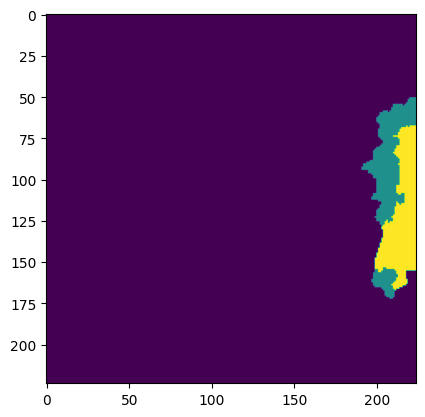

In [66]:
plt.imshow(labels)

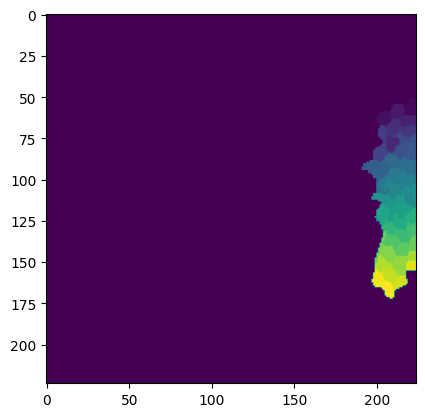

In [64]:
plt.imshow(segments_remapped)

In [65]:
superpixel_gt_labels

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [66]:
from sklearn.metrics import normalized_mutual_info_score as NMI

In [67]:
data.y = torch.tensor(superpixel_gt_labels, dtype=torch.long)
data

Data(x=[44, 1024], edge_index=[2, 1936], edge_weight=[1936], y=[44])

In [74]:
def train():
    model.train()
    optimizer.zero_grad()
    _, s, loss = model(data.x, data.edge_index, data.edge_weight)
    
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def test():
    model.eval()
    _, clust, _= model(data.x, data.edge_index, data.edge_weight)
    return NMI(clust.squeeze().max(1)[1].cpu(), data.y.cpu())

In [75]:
patience = 50
best_nmi = 0
for epoch in range(1, 10000):
    train_loss = train()
    nmi = test()
    print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, NMI: {nmi:.3f}')
    if nmi > best_nmi:
        best_nmi = nmi
        patience = 50
    else:
        patience -= 1     
    if patience == 0:
        break

Epoch: 001, Loss: -0.2292, NMI: 1.000
Epoch: 002, Loss: -0.2292, NMI: 1.000
Epoch: 003, Loss: -0.2292, NMI: 1.000
Epoch: 004, Loss: -0.2292, NMI: 1.000
Epoch: 005, Loss: -0.2292, NMI: 1.000
Epoch: 006, Loss: -0.2292, NMI: 1.000
Epoch: 007, Loss: -0.2292, NMI: 1.000
Epoch: 008, Loss: -0.2292, NMI: 1.000
Epoch: 009, Loss: -0.2292, NMI: 1.000
Epoch: 010, Loss: -0.2292, NMI: 1.000
Epoch: 011, Loss: -0.2292, NMI: 1.000
Epoch: 012, Loss: -0.2292, NMI: 1.000
Epoch: 013, Loss: -0.2292, NMI: 1.000
Epoch: 014, Loss: -0.2292, NMI: 1.000
Epoch: 015, Loss: -0.2292, NMI: 1.000
Epoch: 016, Loss: -0.2292, NMI: 1.000
Epoch: 017, Loss: -0.2292, NMI: 1.000
Epoch: 018, Loss: -0.2292, NMI: 1.000
Epoch: 019, Loss: -0.2292, NMI: 1.000
Epoch: 020, Loss: -0.2292, NMI: 1.000
Epoch: 021, Loss: -0.2292, NMI: 1.000
Epoch: 022, Loss: -0.2292, NMI: 1.000
Epoch: 023, Loss: -0.2292, NMI: 1.000
Epoch: 024, Loss: -0.2292, NMI: 1.000
Epoch: 025, Loss: -0.2292, NMI: 1.000
Epoch: 026, Loss: -0.2292, NMI: 1.000
Epoch: 027, 

In [60]:
from skimage import segmentation, color

In [44]:
img = gt_output.item()['original_image']

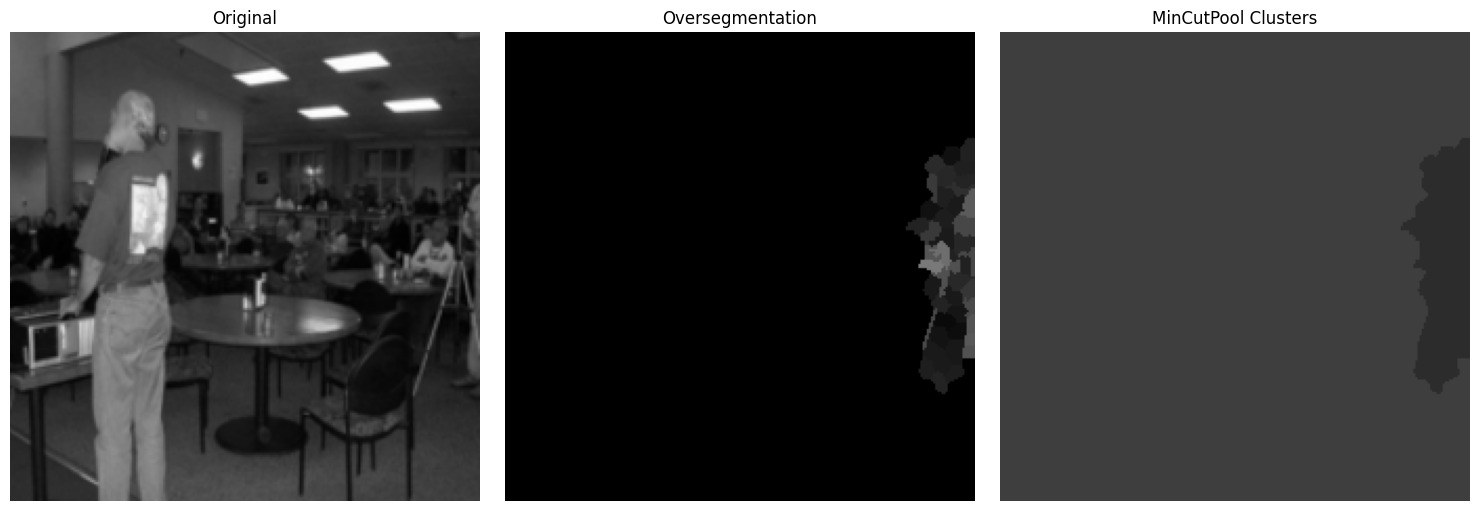

In [61]:
# --- PLOTTING ---
out_seg = color.label2rgb(segments, img, kind='avg')
out_clust = color.label2rgb(labels, img, kind='avg')
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img)
ax[0].set_title("Original")
ax[1].imshow(out_seg)
ax[1].set_title("Oversegmentation")
ax[2].imshow(out_clust)
ax[2].set_title("MinCutPool Clusters")
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()